# Problem 2: Computing Covariances from Data

In [2]:
# Import libraries and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any

# read in the data from the two files
imu_df = pd.read_csv("./imu1.csv")  # replace filepath with yours
vicon_df = pd.read_csv("./vi1.csv")  # replace filepath with yours

In [3]:
# Display a preview of the data
with pd.option_context('display.expand_frame_repr', False):
    print("IMU Data:")
    print(imu_df.head())

    print("Vicon Data:")
    print(vicon_df.head())

IMU Data:
           Time  attitude_roll_radians  attitude_pitch_radians  attitude_yaw_radians  rotation_rate_x_rad_per_sec  rotation_rate_y_rad_per_sec  rotation_rate_z_rad_per_s  gravity_x_G  gravity_y_G  gravity_z_G  user_acc_x_G  user_acc_y_G  user_acc_z_G  magnetic_field_x_microteslas  magnetic_field_y_microteslas  magnetic_field_z_microteslas
0  1.528386e+09              -0.098336                0.412141              0.224581                    -0.598061                     0.991373                   0.558243    -0.089956    -0.400572    -0.911838      0.336615      0.136839     -0.407513                     13.448853                    -13.443630                    -35.590454
1  1.528386e+09              -0.095373                0.409146              0.226051                    -0.710377                     1.029620                   0.533786    -0.087359    -0.397823    -0.913275      0.324242      0.146572     -0.404438                     13.610510                    -13.4056

## Part 1: Exploring the Dataset

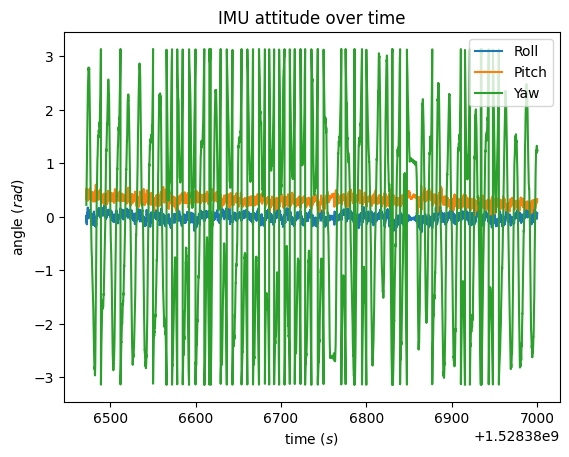

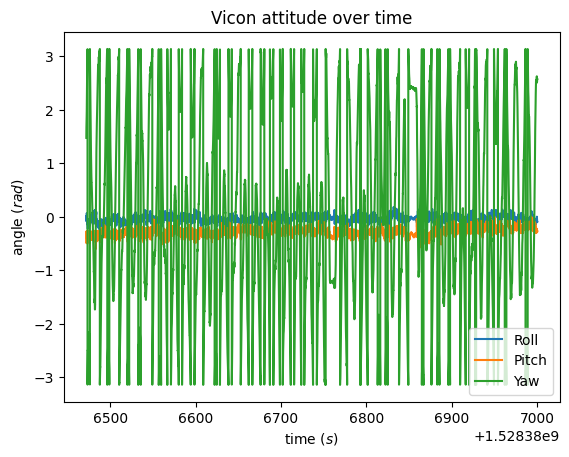

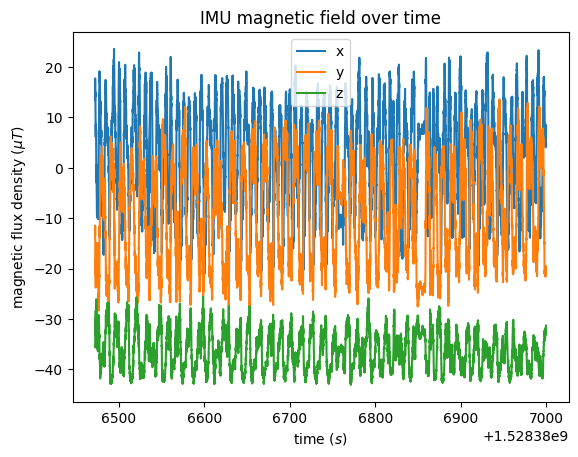

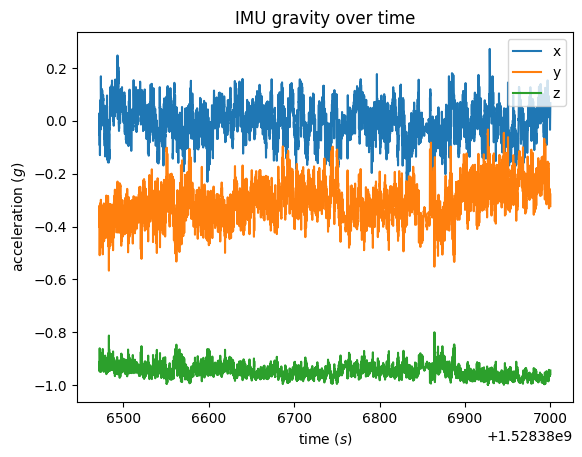

In [4]:
# Plot different readings over time
plt.plot(imu_df['Time'], imu_df['attitude_roll_radians'])
plt.plot(imu_df['Time'], imu_df['attitude_pitch_radians'])
plt.plot(imu_df['Time'], imu_df['attitude_yaw_radians'])

plt.title('IMU attitude over time')
plt.xlabel(r'time ($s$)')
plt.ylabel(r'angle ($rad$)')
plt.legend(['Roll', 'Pitch', 'Yaw'])

plt.show()

plt.plot(vicon_df['Time'], vicon_df['roll'])
plt.plot(vicon_df['Time'], vicon_df['pitch'])
plt.plot(vicon_df['Time'], vicon_df['yaw'])

plt.title('Vicon attitude over time')
plt.xlabel(r'time ($s$)')
plt.ylabel(r'angle ($rad$)')
plt.legend(['Roll', 'Pitch', 'Yaw'])

plt.show()

plt.plot(imu_df['Time'], imu_df['magnetic_field_x_microteslas'])
plt.plot(imu_df['Time'], imu_df['magnetic_field_y_microteslas'])
plt.plot(imu_df['Time'], imu_df['magnetic_field_z_microteslas'])

plt.title('IMU magnetic field over time')
plt.xlabel(r'time ($s$)')
plt.ylabel(r'magnetic flux density ($\mu T$)')
plt.legend(['x', 'y', 'z'])

plt.show()

plt.plot(imu_df['Time'], imu_df['gravity_x_G'])
plt.plot(imu_df['Time'], imu_df['gravity_y_G'])
plt.plot(imu_df['Time'], imu_df['gravity_z_G'])

plt.title('IMU gravity over time')
plt.xlabel(r'time ($s$)')
plt.ylabel(r'acceleration ($g$)')
plt.legend(['x', 'y', 'z'])

plt.show()

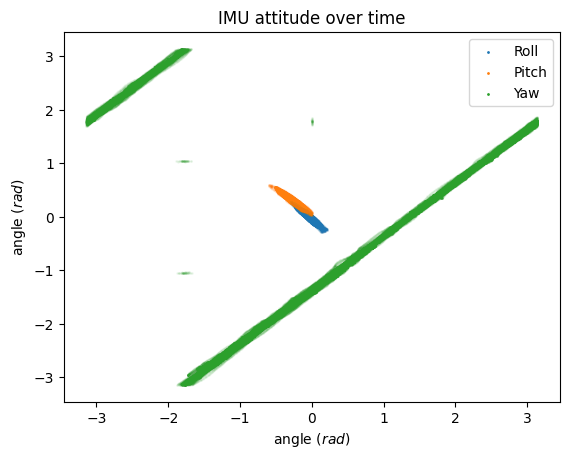

In [5]:
# Plot different readings compared to eachother
options = {
    's': 1,
    'alpha': 0.05,
}

plt.scatter(vicon_df['roll'], imu_df['attitude_roll_radians'], **options) # type: ignore
plt.scatter(vicon_df['pitch'], imu_df['attitude_pitch_radians'], **options) # type: ignore
plt.scatter(vicon_df['yaw'], imu_df['attitude_yaw_radians'], **options) # type: ignore

plt.title('IMU attitude over time')
plt.xlabel(r'angle ($rad$)')
plt.ylabel(r'angle ($rad$)')
legend = plt.legend(['Roll', 'Pitch', 'Yaw'])

for legend_handle in legend.legend_handles:
    legend_handle.set_alpha(1) # type: ignore
plt.show()

## Part B: Comparing IMU Axes

In [6]:
# Function to compute and print the covariance and correlation coefficient matrices for a list of columns in `imu_df`
def compute_and_print_cov_and_corrcoef(columns: list[str], name: str, numpy_printoptions: dict[str, Any] = {}):
    data = imu_df[columns].to_numpy()
    cov = np.cov(data, rowvar=False)
    corrcoef = np.corrcoef(data, rowvar=False)

    with np.printoptions(**numpy_printoptions):
        print(f'Covariance and correlation coefficient matrices for {name}\nCovariance matrix:\n{cov}\nCorrelation coefficient matrix:\n{corrcoef}\n')


In [7]:
# Compute the covariance and correlation coefficient matrices for various readings
compute_and_print_cov_and_corrcoef(
    ['user_acc_x_G', 'user_acc_y_G', 'user_acc_z_G'], 
    'acceleration in all three axes (x, y, z)',
)
compute_and_print_cov_and_corrcoef(
    ['attitude_yaw_radians', 'attitude_pitch_radians', 'attitude_roll_radians'],
    'attitude in all three axes (yaw, pitch, roll)',
)
compute_and_print_cov_and_corrcoef(
    ['rotation_rate_x_rad_per_sec', 'rotation_rate_y_rad_per_sec', 'rotation_rate_z_rad_per_s'],
    'rate of rotation in all three axes (yaw, pitch roll)',
)
compute_and_print_cov_and_corrcoef(
    [
        'gravity_x_G', 'gravity_y_G', 'gravity_z_G', 
        'magnetic_field_x_microteslas', 'magnetic_field_y_microteslas', 'magnetic_field_z_microteslas',
        'user_acc_x_G', 'user_acc_y_G', 'user_acc_z_G',
    ],
    'gravity, magnetic field, and acceleration for each of the three axes (x, y, z)',
    {
        'precision': 4,
        'suppress': True,
        'linewidth': 100,
    }
)
compute_and_print_cov_and_corrcoef(
    [
        'rotation_rate_x_rad_per_sec', 'rotation_rate_y_rad_per_sec', 'rotation_rate_z_rad_per_s', 
        'user_acc_x_G', 'user_acc_y_G', 'user_acc_z_G',
    ],
    'rate of rotation and acceleration for each of the three axes (x, y, z)',
    {
        'precision': 6,
        'suppress': True,
        'linewidth': 100,
    }
)


Covariance and correlation coefficient matrices for acceleration in all three axes (x, y, z)
Covariance matrix:
[[ 2.26456107e-02 -4.71148351e-03 -5.26712019e-05]
 [-4.71148351e-03  1.35404957e-02 -1.05112843e-03]
 [-5.26712019e-05 -1.05112843e-03  4.04986117e-02]]
Correlation coefficient matrix:
[[ 1.         -0.26905953 -0.00173925]
 [-0.26905953  1.         -0.04488678]
 [-0.00173925 -0.04488678  1.        ]]

Covariance and correlation coefficient matrices for attitude in all three axes (yaw, pitch, roll)
Covariance matrix:
[[ 3.20040253e+00  8.02045917e-03 -1.45880596e-04]
 [ 8.02045917e-03  5.64988258e-03 -7.82262882e-04]
 [-1.45880596e-04 -7.82262882e-04  4.69720699e-03]]
Correlation coefficient matrix:
[[ 1.          0.05964544 -0.0011898 ]
 [ 0.05964544  1.         -0.15184943]
 [-0.0011898  -0.15184943  1.        ]]

Covariance and correlation coefficient matrices for rate of rotation in all three axes (yaw, pitch roll)
Covariance matrix:
[[ 0.28665589 -0.0680202   0.08761712

## Part C: Comparing IMU with Vicon Ground Truth

In [8]:
# Compute the covariance and correlation coefficient matrices between IMU and Vicon
imu_data = imu_df[['attitude_yaw_radians', 'attitude_pitch_radians', 'attitude_roll_radians']].to_numpy()
vicon_data = vicon_df[['yaw', 'pitch', 'roll']].to_numpy()

# Name, IMU, Vicon
axes: list[tuple[str, pd.Series, pd.Series]] = [
    ('yaw', imu_df['attitude_yaw_radians'], vicon_df['yaw']),
    ('pitch', imu_df['attitude_pitch_radians'], vicon_df['pitch']),
    ('roll', imu_df['attitude_roll_radians'], vicon_df['roll']),
]

for axis in axes:
    cov = np.cov(axis[1], axis[2], rowvar=False)
    corrcoef = np.corrcoef(axis[1], axis[2], rowvar=False)

    print(f'Covariance and correlation coefficient matrices between IMU and Vicon {axis[0]} attitude\nCovariance matrix:\n{cov}\nCorrelation coefficient matrix:\n{corrcoef}\n')
        

Covariance and correlation coefficient matrices between IMU and Vicon yaw attitude
Covariance matrix:
[[3.20040253 0.4934338 ]
 [0.4934338  3.37645584]]
Correlation coefficient matrix:
[[1.         0.15010531]
 [0.15010531 1.        ]]

Covariance and correlation coefficient matrices between IMU and Vicon pitch attitude
Covariance matrix:
[[ 0.00564988 -0.00551346]
 [-0.00551346  0.00582664]]
Correlation coefficient matrix:
[[ 1.        -0.9609371]
 [-0.9609371  1.       ]]

Covariance and correlation coefficient matrices between IMU and Vicon roll attitude
Covariance matrix:
[[ 0.00469721 -0.00395212]
 [-0.00395212  0.00375064]]
Correlation coefficient matrix:
[[ 1.         -0.94157978]
 [-0.94157978  1.        ]]



yaw:
  mean: 0.2797733024591584
  variance: 5.589955430865611


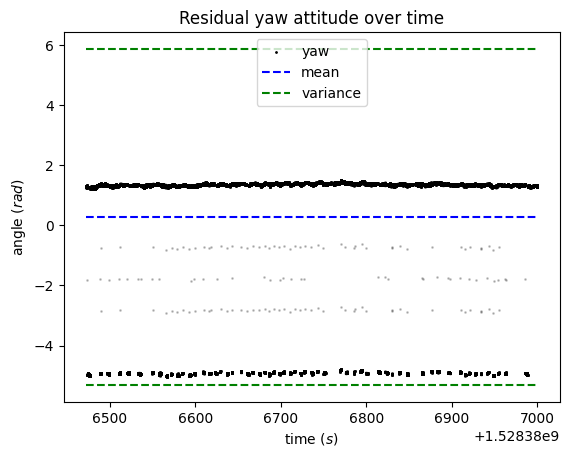

pitch:
  mean: -0.5780861786652727
  variance: 0.022503293896960434


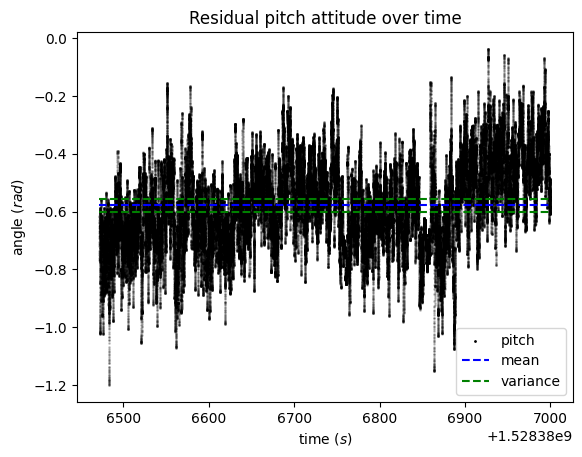

roll:
  mean: -0.034210081443614336
  variance: 0.016351981045985963


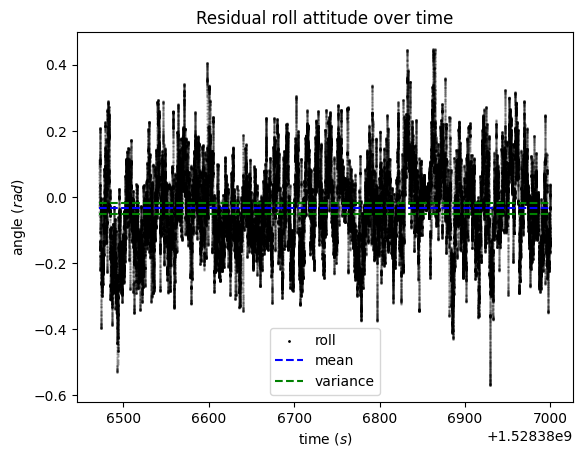

In [9]:
# Compute and plot the residuals for each axis over time, along with the means and standard deviation
for axis in axes:
    residuals = axis[2] - axis[1]
    mean = np.mean(residuals)
    variance = np.var(residuals)

    print(f'{axis[0]}:\n  mean: {mean}\n  variance: {variance}')

    plt.scatter(imu_df['Time'], residuals, s=1, alpha=0.2, color='black')
    plt.plot([imu_df['Time'].iloc[0], imu_df['Time'].iloc[-1]], [mean, mean], color='blue', ls='--')
    plt.plot([imu_df['Time'].iloc[0], imu_df['Time'].iloc[-1]], [mean + variance, mean + variance], color='green', ls='--')
    plt.plot([imu_df['Time'].iloc[0], imu_df['Time'].iloc[-1]], [mean - variance, mean - variance], color='green', ls='--')

    plt.title(f'Residual {axis[0]} attitude over time')
    plt.xlabel(r'time ($s$)')
    plt.ylabel(r'angle ($rad$)')
    legend = plt.legend([axis[0], 'mean', 'variance'])

    for legend_handle in legend.legend_handles:
        legend_handle.set_alpha(1) # type: ignore

    plt.show()

The residual variance and the relational covariances seem to be related. Yaw has high variance and larger numbers in it's covariance matrix, and pitch and roll have much smaller values in both.

## Part D: Today’s So What

* I find it interesting that there is sometimes a bit of correlation between the same readings for different axes. For instance, x and y acceleration and pitch and roll rate of rotation. I wonder if that has to do with the orientation of the IMU and the specific type of repeating motion it's measuring. 

* The results of the covariance and correlation coefficient analysis show us important measures about the noise in the data, but miss the shape or other smaller timescale trends in the data. These are shown in the residuals plot. For example, the residuals plot for pitch over time shows that the noise is somewhat time dependent, and that there are spikes. This means that using uniform noise probably won't capture the real behavior of the sensors, and that there's definitely dependence we need to take into account. The correlation coefficient between the IMU data and the Vicon data can tell us about the amount of unexplained variance (magnitude of noise) in each axis. We do have to be a little careful with this though because, as stated earlier, there are many intricacies and dependencies that we may or may not need to also consider.
    * Linearity: The residuals plot can help us understand how uniform the noise is, and covariance can help us see if there is a linear relationship between two variables.
    * Magnitude of relational covariance: can tell us the level of unexplianed variance (noise) between ground truth and noisy data.
    * Sign of relational covariance: can tell us if there is a proportional or inversely proportional relationship between the ground truth data and noisy data.
    * Magnitude of residual variance: another measure of noise.
    * Mean of the residuals: a measure of the expected offset between the ground truth data and the noisy data.
* We can trust it decently well, but should expect different axes to vary by anywhere from a few percent to most of the measurement. For example, pitch and yaw can be trusted a lot, within about 5%, but yaw can be much, much further off from ground truth.